### Create SMET Forcing Files from Met Station Data: Point Simulation PPSA2

Notebook contents 
* SNOWPACK takes an SMET file, so let's create that for point simulations

created by Cassie Lumbrazo\
last updated: Feb 2025\
run location: UAS linux\
python environment: **rasterio**

In [7]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [8]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/ppsa2'

## Open PPSA2 Met Station Data

In [9]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met_raw = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met_raw['datetime'] = pd.to_datetime(df_met_raw['utc_valid'], utc=True)
df_met_raw = df_met_raw.set_index('datetime')

# create a dataframe, df_met, which contains only the datetime, PCIRZZZ, SDIRZZZ, TAIRZZZ, XRIRZZZ
df_met = df_met_raw[['PCIRZZZ', 'SDIRZZZ', 'TAIRZZZ', 'XRIRZZZ']].copy()

# cut to the same datetime as hrrr-ak
df_met = df_met.loc['2024-10-01T05:00':'2025-06-01T00:00']

# remove any PCIRZZZ values that are above 150
df_met['precip_accum_total'] = (df_met['PCIRZZZ'].where(df_met['PCIRZZZ'] <= 150)) * 25.4 # convert from inches to mm

# now, calculate the precipitation rate in mm/hr from the cumulative precip, and then convert to mm/s to compare with the model output
# df_met['precip_rate'] = df_met['precip_accum_total'].diff() / 1 # convert from mm/hr to mm/s (since the data is hourly, diff() gives us the change in precip per hour, so we divide by 1 to get mm/hr, then

# compute diff
diff = df_met["precip_accum_total"].diff()

# detect time gaps
time_diff = df_met.index.to_series().diff().dt.total_seconds()

# mask bad intervals
bad = (
    df_met["precip_accum_total"].isna() |
    df_met["precip_accum_total"].shift(1).isna() |
    (time_diff > 3600)
)

df_met["precip_accum_1hr"] = diff.mask(bad)

# get all the variables consistent first 
df_met['RH'] = df_met['XRIRZZZ']
df_met['HS'] = df_met['SDIRZZZ'] * 2.54 # convert from inches to mm, this is the snow depth in mm

# lightly clean HS so that no values are over 250cm 
df_met['HS'] = df_met['HS'].where(df_met['HS'] < 250, np.nan)

df_met['TA'] = (df_met['TAIRZZZ'] - 32) * 5/9 # convert from F to C
df_met.head()

,PCIRZZZ,SDIRZZZ,TAIRZZZ,XRIRZZZ,precip_accum_total,precip_accum_1hr,RH,HS,TA
datetime,,,,,,,,,
2024-10-01 05:00:00+00:00,278.62,17.08,37.2,92.6,NaN,NaN,92.6,43.3832,2.888889
2024-10-01 06:00:00+00:00,278.66,17.28,37.5,93.3,NaN,NaN,93.3,43.8912,3.055556
2024-10-01 07:00:00+00:00,278.66,17.08,38.2,93.8,NaN,NaN,93.8,43.3832,3.444444
2024-10-01 08:00:00+00:00,278.70,16.48,39.1,92.5,NaN,NaN,92.5,41.8592,3.944444
2024-10-01 09:00:00+00:00,278.70,17.28,39.7,91.5,NaN,NaN,91.5,43.8912,4.277778


## Load the HRRR Dataset, 

In [10]:
input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_ppsa2.nc"
ds = xr.open_dataset(input_file)
ds.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

ds['precip_accum_1hr'] = ds['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

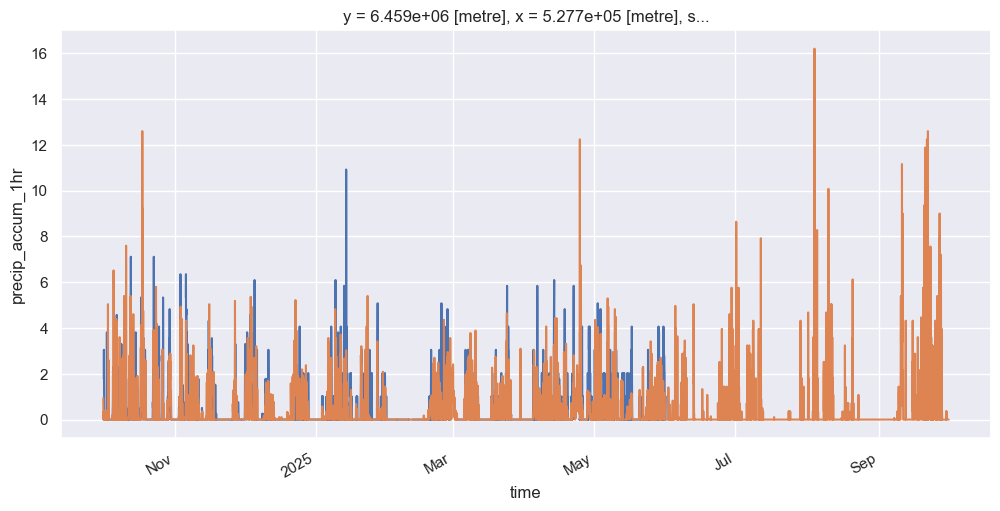

In [11]:
df_met['precip_accum_1hr'].plot()
ds['precip_accum_1hr'].plot()

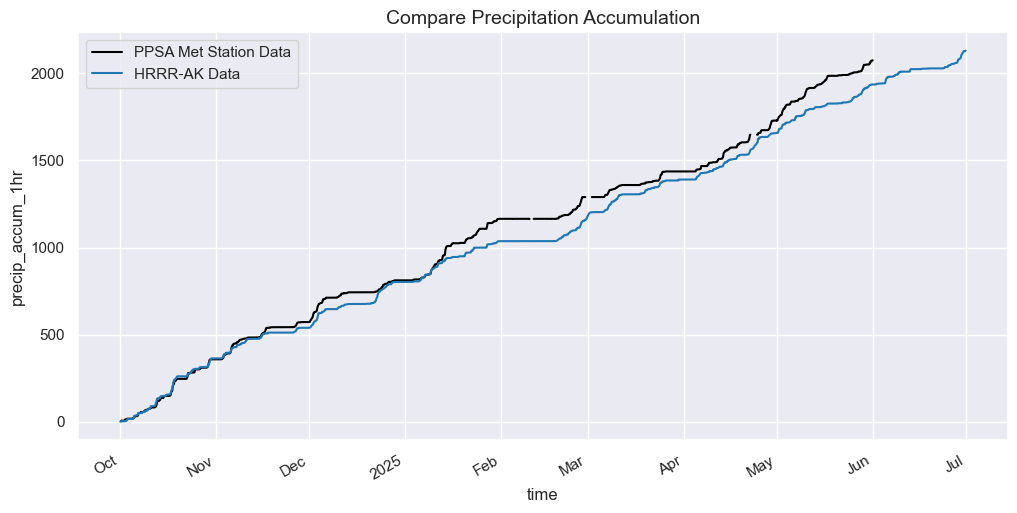

In [32]:
df_met['precip_accum_1hr'].cumsum().plot(label='PPSA Met Station Data', color='black')
ds['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')
plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [12]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

This version dealing with the timestepping, and precipiation units over that timestep

In [13]:
lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [43]:
# Make ds time UTC-aware
# time = pd.to_datetime(ds.time.values).tz_localize("UTC")

# Or alternatively, strip timezone from df_met:
df_met.index = df_met.index.tz_convert(None)

New code, 

df_met time range: 2024-10-01 05:00:00 to 2025-06-01 00:00:00
ds time range: 2024-10-01T05:00:00.000000000 to 2025-07-01T00:00:00.000000000
Original met data coverage:
0.995409604519774
After reindex to HRRR time:
0.8610262675626146
First few aligned values:
2024-10-01 05:00:00      NaN
2024-10-01 06:00:00      NaN
2024-10-01 07:00:00      NaN
2024-10-01 08:00:00      NaN
2024-10-01 09:00:00      NaN
2024-10-01 10:00:00      NaN
2024-10-01 11:00:00    1.778
2024-10-01 12:00:00    3.048
2024-10-01 13:00:00    1.524
2024-10-01 14:00:00    0.254
Name: precip_accum_1hr, dtype: float64
Fraction of timesteps using met data:
TA: 0.8649969456322542
RH: 0.8649969456322542
PSUM: 0.8610262675626146
Mixed precipitation differs from HRRR at:
2418 timesteps


SMET file written to: /home/cassie/python/models/run_snowpack/sites/ppsa2/input/met_hrrrak_ppsa2_WY2025.smet


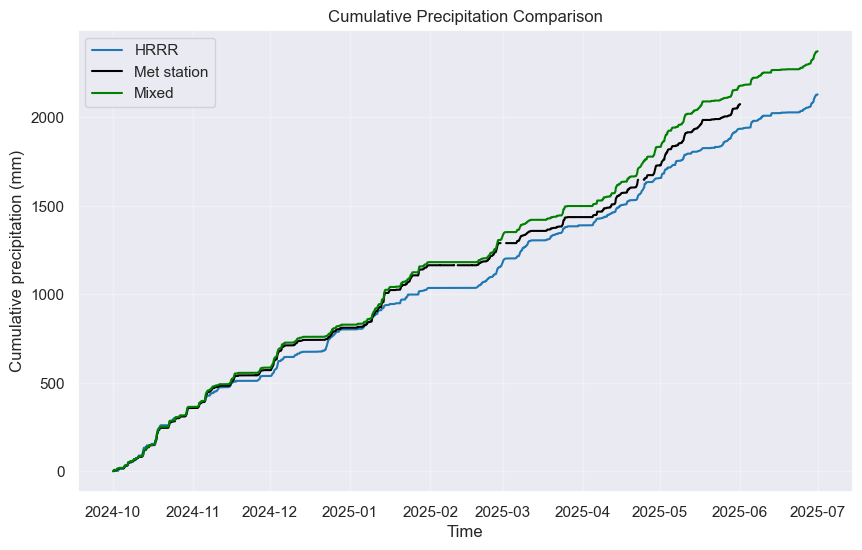

In [53]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# =========================
# SLICE DATASETS TO COMMON TIME RANGE
# =========================
start_time = '2024-10-01T05:00'
end_time = '2025-07-01T00:00'

# Slice df_met (pandas DataFrame)
df_met = df_met.loc[start_time:end_time]

# Slice ds (xarray Dataset)
ds = ds.sel(time=slice(start_time, end_time))

print(f"df_met time range: {df_met.index.min()} to {df_met.index.max()}")
print(f"ds time range: {ds.time.min().values} to {ds.time.max().values}")

# =========================
# UNIT CONVERSIONS AND ALIGNMENT
# =========================
time_index = pd.to_datetime(ds.time.values)

# Convert ds variables
ds_temp_c = ds['temp'].values - 273.15
ds_rh_frac = ds['rh'].values / 100.0
ds_psum = ds['precip_accum_1hr'].values  # mm per timestep

# Align met data to HRRR time grid
# df_met_aligned = df_met.reindex(time_index) # trying the code below instead 

# Ensure datetime index
df_met.index = pd.to_datetime(df_met.index)

# Resample met data to hourly grid
df_met_hourly = df_met.resample("1h").mean()

# Align to HRRR time index
df_met_aligned = df_met_hourly.reindex(time_index)


print("Original met data coverage:")
print(df_met['precip_accum_1hr'].notna().mean())

print("After reindex to HRRR time:")
print(df_met_aligned['precip_accum_1hr'].notna().mean())

print("First few aligned values:")
print(df_met_aligned['precip_accum_1hr'].head(10))


# Convert met RH to fraction if needed
if df_met_aligned['RH'].max() > 1:
    df_met_aligned['RH'] = df_met_aligned['RH'] / 100.0

# =========================
# CREATE FILLED DATAFRAME
# =========================
df_filled = pd.DataFrame(index=time_index)

# Temperature
df_filled['TA'] = df_met_aligned['TA'].fillna(
    pd.Series(ds_temp_c, index=time_index)
)

# Relative humidity
df_filled['RH'] = df_met_aligned['RH'].fillna(
    pd.Series(ds_rh_frac, index=time_index)
)

# Precipitation (correct column name!)
df_filled['PSUM'] = df_met_aligned['precip_accum_1hr'].fillna(
    pd.Series(ds_psum, index=time_index)
)

print("Fraction of timesteps using met data:")
print("TA:", df_met_aligned['TA'].notna().mean())
print("RH:", df_met_aligned['RH'].notna().mean())
print("PSUM:", df_met_aligned['precip_accum_1hr'].notna().mean())

print("Mixed precipitation differs from HRRR at:")
print((df_filled["PSUM"] != ds_psum).sum(), "timesteps")


# =========================
# USER SETTINGS FOR SMET
# =========================
OUTFILE = Path("/home/cassie/python/models/run_snowpack/sites/ppsa2/input/met_hrrrak_ppsa2_WY2025.smet")

STATION_ID = "met_hrrrak_ppsa2_WY2025"
STATION_NAME = "Met Station and HRRR-AK Powder Patch Point Forcing"
LAT = lat_ppsa2  # Define these variables
LON = lon_ppsa2
ELEV = elevation_ppsa2
EPSG = 32608
TZ = 0
NODATA = -999

# -------------------------
# SIMULATION TIMESTEP
# -------------------------
TIMESTEP = "1h"
TIMESTEP_SECONDS = pd.to_timedelta(TIMESTEP).total_seconds()

# =========================
# COORDINATE TRANSFORM
# =========================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
EASTING, NORTHING = transformer.transform(LON, LAT)

# =========================
# BUILD DATAFRAME FOR SMET
# =========================
# Use df_filled as base, add other required variables from ds
df = df_filled.copy()

# Add other variables from ds (assuming they are available)
df["ISWR"] = ds['swrad'].values  # W/m²
df["ILWR"] = ds['lwrad'].values  # W/m²
df["PS"] = ds['pressure'].values  # Pa

# Wind from ds
u = ds['10u'].values
v = ds['10v'].values
df["VW"] = np.sqrt(u**2 + v**2)  # m/s
df["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0  # degrees

# Precipitation: Use PSUM from df_filled (mm accum per timestep)

# =========================
# UNIT CONVERSIONS FOR SMET
# =========================
# Convert TA from C to K (SMET expects Kelvin)
df["TA"] = df["TA"] + 273.15

# RH is already in fraction (0-1)
# VW: m/s
# DW: degrees
# ISWR: W/m²
# ILWR: W/m²
# PSUM: mm per timestep
# PS: Pa

# =========================
# RESAMPLE TO MODEL TIMESTEP
# =========================
mean_vars = ["TA", "RH", "VW", "DW", "ISWR", "ILWR", "PS"]
sum_vars = ["PSUM"]

df_mean = df[mean_vars].resample(TIMESTEP).mean()
df_sum = df[sum_vars].resample(TIMESTEP).sum()
df = pd.concat([df_mean, df_sum], axis=1)

# Replace missing values
df = df.fillna(NODATA)

# =========================
# WRITE SMET
# =========================
with open(OUTFILE, "w") as f:
    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")
    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")
    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")
    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")
    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")
    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")
    f.write("source           = df_met filled with HRRR-AK\n")
    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")

    for t, row in df.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} {row.RH:6.3f} "
            f"{row.VW:6.2f} {row.DW:6.1f} "
            f"{row.ISWR:8.1f} {row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} {row.PS:8.1f}\n"
        )

print(f"SMET file written to: {OUTFILE}")

# =========================
# PLOT FORCING DATA
# =========================
# # Variables to plot (from SMET fields)
# variables = ['TA', 'RH', 'VW', 'DW', 'ISWR', 'ILWR', 'PSUM', 'PS']

# # Unit labels for y-axes
# unit_labels = {
#     'TA': 'K',
#     'RH': 'fraction',
#     'VW': 'm s⁻¹',
#     'DW': 'degrees',
#     'ISWR': 'W m⁻²',
#     'ILWR': 'W m⁻²',
#     'PSUM': 'mm',
#     'PS': 'Pa'
# }

# # Create subplots: 8 rows, 1 column
# fig, axes = plt.subplots(8, 1, figsize=(12, 16), sharex=True)

# for i, var in enumerate(variables):
#     ax = axes[i]
#     # Plot the variable, excluding NODATA values
#     data = df[var].replace(NODATA, np.nan)
#     ax.plot(df.index, data, linewidth=1.5)
#     ax.set_ylabel(f"{var} ({unit_labels.get(var, '')})", fontsize=10)
#     ax.grid(True, alpha=0.3)

# # Set common x-label
# axes[-1].set_xlabel("Time", fontsize=12)

# # Overall title
# fig.suptitle("SMET Forcing Data Time Series", fontsize=16)

# # Adjust layout
# plt.tight_layout(rect=[0, 0, 1, 0.96])

# =========================
# PRECIP COMPARISON PLOT
# =========================
plt.figure(figsize=(10,6))

# HRRR precip
hrrr_psum = pd.Series(ds_psum, index=time_index)
plt.plot(hrrr_psum.cumsum(), label="HRRR", color='tab:blue')

# Met station precip
met_psum = df_met_aligned['precip_accum_1hr']
plt.plot(met_psum.cumsum(), label="Met station", color='black')

# Mixed precip
mix_psum = df_filled['PSUM']
plt.plot(mix_psum.cumsum(), label="Mixed", color='green')

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Cumulative Precipitation Comparison")
plt.show()

In [46]:
print("Totals (mm):")
print("Met:", df_met_aligned["precip_accum_1hr"].sum())
print("HRRR:", ds_psum.sum())
print("Mixed:", df["PSUM"].replace(NODATA, np.nan).sum())


Totals (mm):
Met: 2074.9260000000004
HRRR: 2130.1560002059937
Mixed: 2373.87


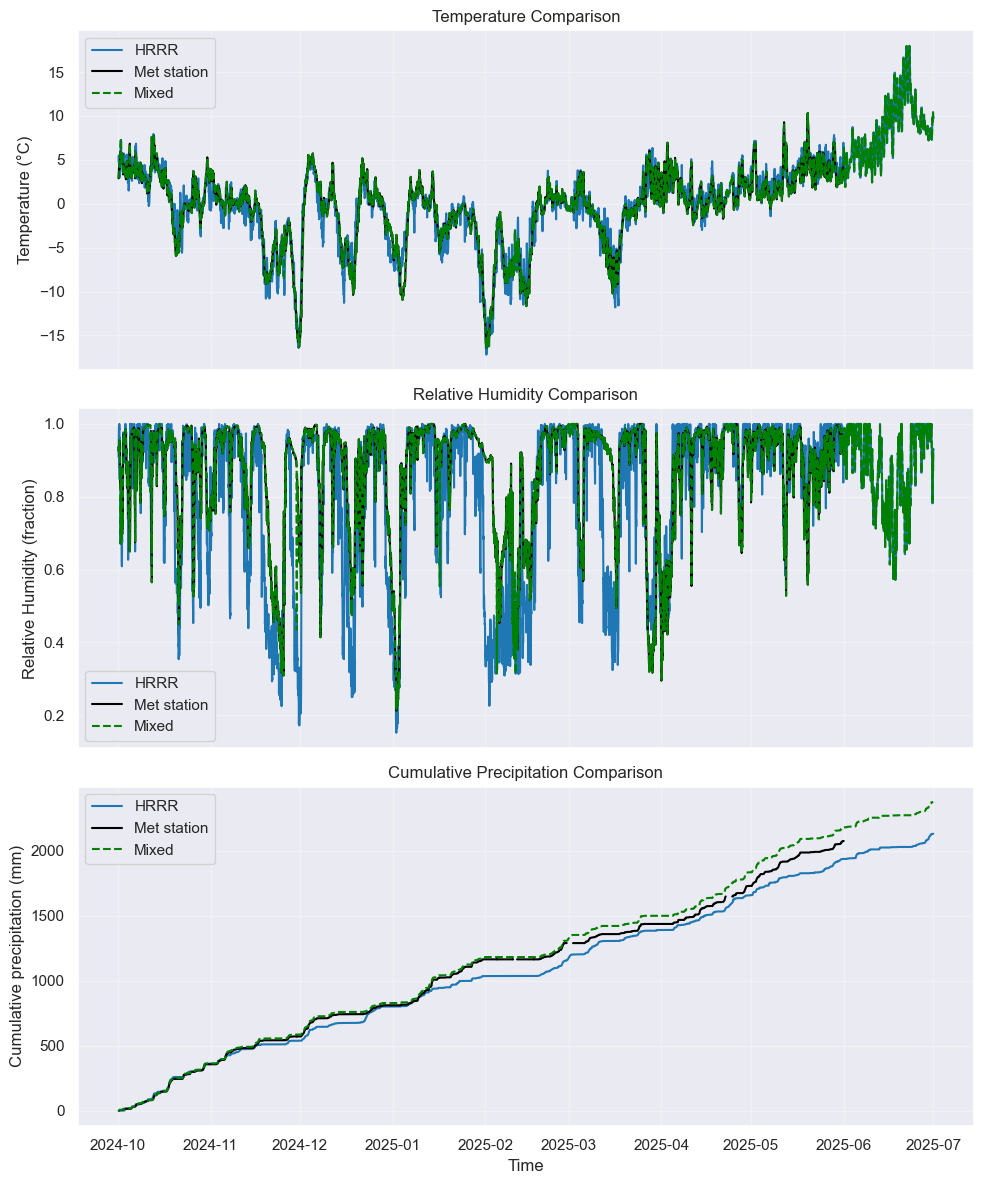

In [54]:
# =========================
# MULTI-VARIABLE COMPARISON PLOT
# =========================
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# -------------------------
# Temperature (TA)
# -------------------------
ax = axes[0]

# HRRR temperature (convert K → C if needed)
hrrr_ta = pd.Series(ds['temp'].values - 273.15, index=time_index)

# Met temperature (already in C)
met_ta = df_met_aligned['TA']

# Mixed temperature (convert back from K → C)
mix_ta = df_filled['TA']

ax.plot(hrrr_ta, label="HRRR", color='tab:blue')
ax.plot(met_ta, label="Met station", color='black')
ax.plot(mix_ta, label="Mixed", color='green', linestyle='--')

ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Relative Humidity (RH)
# -------------------------
ax = axes[1]

# HRRR RH (fraction)
hrrr_rh = pd.Series(ds['rh'].values / 100.0, index=time_index)

# Met RH (convert to fraction if needed)
met_rh = df_met_aligned['RH']
if met_rh.max() > 1:
    met_rh = met_rh / 100.0

# Mixed RH
mix_rh = df_filled['RH']

ax.plot(hrrr_rh, label="HRRR", color='tab:blue')
ax.plot(met_rh, label="Met station", color='black')
ax.plot(mix_rh, label="Mixed", color='green', linestyle='--')

ax.set_ylabel("Relative Humidity (fraction)")
ax.set_title("Relative Humidity Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Precipitation (cumulative)
# -------------------------
ax = axes[2]

# HRRR precip
hrrr_psum = pd.Series(ds_psum, index=time_index)

# Met precip
met_psum = df_met_aligned['precip_accum_1hr']

# Mixed precip
mix_psum = df_filled['PSUM']

ax.plot(hrrr_psum.cumsum(), label="HRRR", color='tab:blue')
ax.plot(met_psum.cumsum(), label="Met station", color='black')
ax.plot(mix_psum.cumsum(), label="Mixed", color='green', linestyle='--')

ax.set_ylabel("Cumulative precipitation (mm)")
ax.set_title("Cumulative Precipitation Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Common x-axis
# -------------------------
axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()
